# Project Description

The goal of this project is to predict how likely a borrower is to default on a loan using demographic, financial, and loan-related features.

The target variable is "loan_status" with it having two values:
1. 0 = loan has been paid back
2. 1 = loan defaulted

This is a Binary Classification because there are only two outcomes, namely: default vs non-default.

# Imports/Dependencies

# Important Libraries

- <b><u>Pandas</u></b>: Used to handle the dataset and helps with cleaning and processing.
- <b><u>MathPlotLib</b> and Seaborn</u>: Used for data visualization and gaining a better insight.
- <b><u>Sklearn</u></b>: This module has various libraries with implemented models which can be used for data evaluation

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, classification_report, log_loss, auc, precision_recall_curve

# Loading and inspecting the dataset

In [181]:
financialDF = pd.read_csv('credit_risk_dataset.csv')

# Learning the Data

In [182]:
# view the first 10 rows of the dataset
financialDF.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [183]:
# check what columns are in the dataset
list(financialDF.columns)

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [184]:
print(f"The shape of the dataframe is: {financialDF.shape}\n")

The shape of the dataframe is: (32581, 12)



In [185]:
print(f"The info of the dataframe is:\n{financialDF.info()}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
The info of the dataframe is:
N

In [186]:
print("Description of the dataset:")
financialDF.describe()

Description of the dataset:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


loan_status
0    25473
1     7108
Name: count, dtype: int64


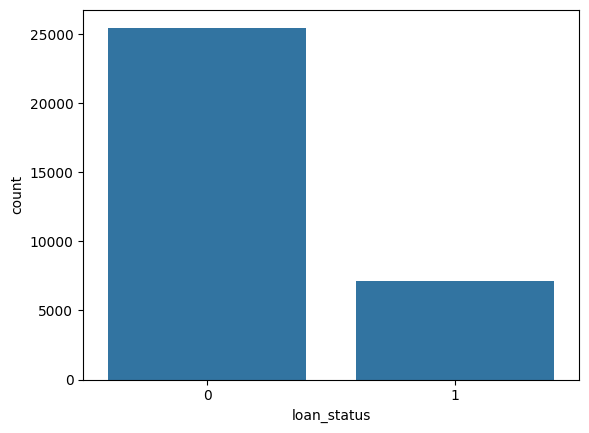

In [187]:
print(financialDF['loan_status'].value_counts())
sns.countplot(x='loan_status', data=financialDF)
plt.show()

# Data Analysis and Cleaning

1. Removing all rows with <u>**NULL**</u> values

In [188]:
# number of empty cells per column before cleaning
print(financialDF.isnull().sum(), f"Original shape of dataframe{financialDF.shape}") # (32561,12)

# remove any row that has a missing value
financialDF.dropna(inplace=True)

print("--------------------------------------------")

# number of empty cells per column after cleaning
print(financialDF.isnull().sum(), f"Shape of updated dataframe{financialDF.shape}") # (28638, 12)

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64 Original shape of dataframe(32581, 12)
--------------------------------------------
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64 Shape of updated dataframe(28638, 12)


2. Removing <u>**Duplicate**</u> values

In [189]:
# prevent the model from learning repeated behavior
financialDF.drop_duplicates(inplace=True)

print(f"Shape of updated dataframe{financialDF.shape}")

Shape of updated dataframe(28501, 12)


3. Removing any <u>**outliers**</u>

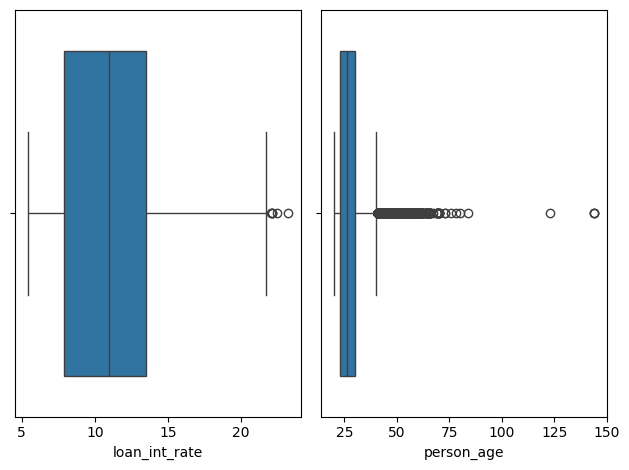

In [190]:
plt.subplot(1, 2, 1)
sns.boxplot(x=financialDF['loan_int_rate'])

plt.subplot(1, 2, 2)
sns.boxplot(x=financialDF['person_age'])

plt.tight_layout()
plt.show()

We can observe that there are some extreme/unrealistic outliers for the age. Thus, I will remove the outliers for any age > 100 to extreme outliers that could skew and influence the result of the model training.

In [191]:
# remove outliers

print("Shape before dealing with outliers: ", financialDF.shape)

financialDF = financialDF[financialDF["person_age"] <= 100]
financialDF = financialDF[financialDF["person_emp_length"] <= 60]

income_99th = financialDF["person_income"].quantile(0.99)
financialDF["person_income"] = np.where(financialDF["person_income"] > income_99th, income_99th, financialDF["person_income"])

print("Shape after dealing with outliers: ", financialDF.shape)


Shape before dealing with outliers:  (28501, 12)
Shape after dealing with outliers:  (28495, 12)


# Exploratory Data Analysis

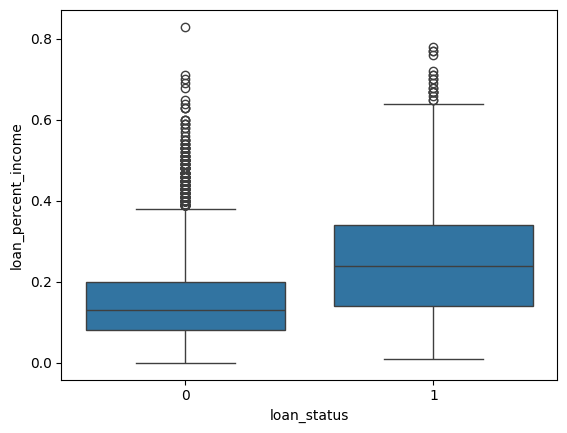

In [192]:
sns.boxplot(x="loan_status", y="loan_percent_income", data=financialDF)
plt.show()

Borrowers who default usually have a higher loan_percent_incom value compared to those who do not default. This reveals that those whose loans are a larget percent of their income find it harder to repay their loans without defaulting.

<Axes: xlabel='loan_grade', ylabel='count'>

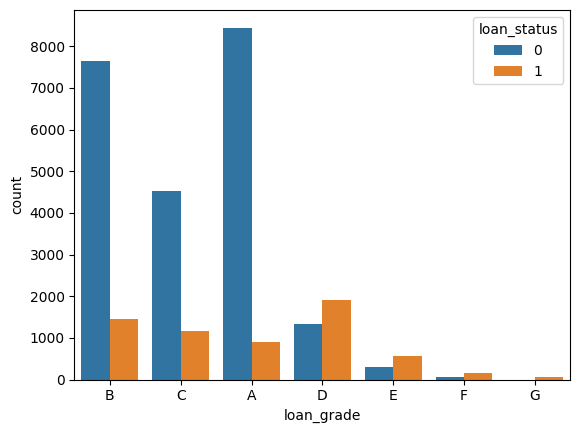

In [193]:
sns.countplot(x='loan_grade', hue='loan_status', data=financialDF)

<Axes: >

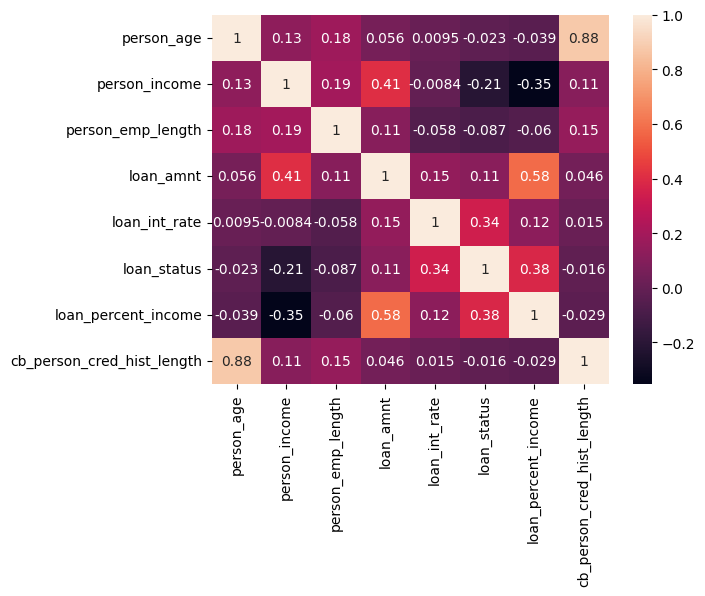

In [194]:
corr = financialDF.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

Creating a correlation heatmap of the dataset shows that for "loan_status", factors that show a strong correlation include: 
1. <u><b>loan_percent_income</b></u> (Positive Correlation): Those whose loan is a larger percent of their income are more likely to default on a loan
2. <u><b>loan_int_rate</b></u> (Positive Correlation): The higher the interest rate of a person, the more likely they are to default on their loan
3. <u><b>person_income</b></u> (Negative Correlation): The more someone makes, the less likely they are to defaulr on their loan
4. <u><b>loan_amount</b></u> (Positive Correlation): The higher the loan amount, the more likely the person is to default on the loan

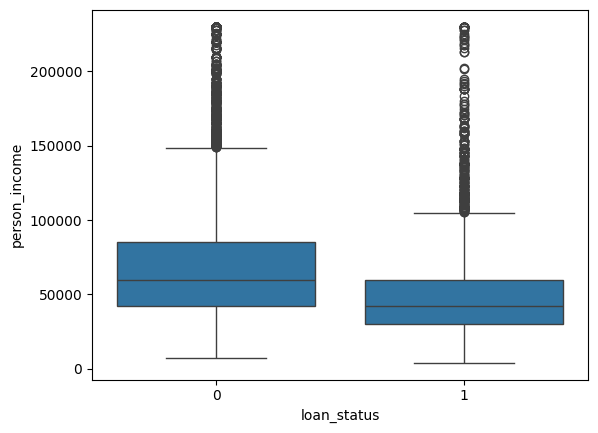

In [195]:
sns.boxplot(x='loan_status', y='person_income', data=financialDF)
plt.show()


Observation: Dafulters tend to have lower income compared to those who don't defualt. Furthermore, huge number of outliers reveals that the data is right skewed.

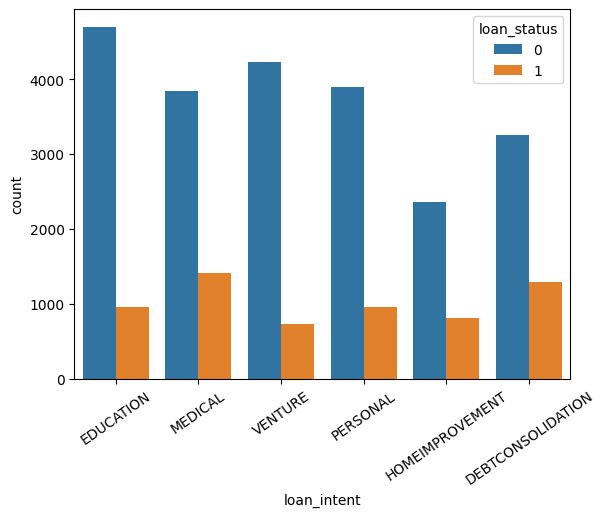

In [196]:
# loan status vs loan intent
sns.countplot(x='loan_intent', hue='loan_status', data=financialDF)
plt.xticks(rotation = 35)
plt.show()

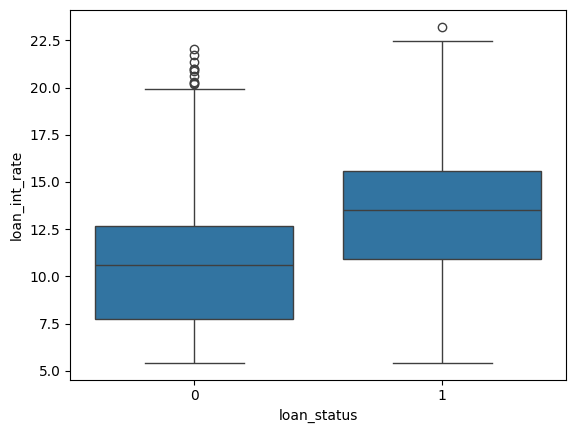

In [197]:
# loan interest rate vs loan status
sns.boxplot(x='loan_status', y='loan_int_rate', data=financialDF)
plt.show()

Observation: Those who did not default generally had a lower interest rate. This suggests that a higher interest rate is associated with an increased default risk.

# Model Training and Analysis

In [198]:
# every attribute which could contribute to the prediction
X = financialDF.drop('loan_status', axis=1)

# attribute to predict
y = financialDF['loan_status']


# this encodes the object/categorical variables, so the model can deal with these values
X = pd.get_dummies(X, drop_first=True)

# 80/20 training/testing split
# random_state ensures reproducibility
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# standardizes features because Logistic Regression is sensitive to Feature Magnitude
scaler_var = StandardScaler()
X_train = scaler_var.fit_transform(x_train)
X_test = scaler_var.transform(x_test)


I decided to use a 80/20 split to train and test my models because I would be able to provide large enough data for the models to recognize complex patterns, while still having large enough data to adequately test my models on unseen data to check for generalization.

### Logistic Regression

I chose to use Logistic Regression, which is a statistical classification algorithm, as I am trying to predict a discrete category, namely loan_status.

In [199]:

# Train the Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)


# Make the prediction for the testing dataset
y_pred = lr_model.predict(X_test)


### Evaluate the performance of the Logistic Regression Model

In [200]:
# Accuracy:
acc = accuracy_score(y_test, y_pred) * 100
print(f"accuracy: {round(acc, 2)}%\n")
print(f"Precentage of non-defults: {(len(financialDF[financialDF["loan_status"] == 0])/len(financialDF["loan_status"])) * 100:.2f}%\n")
print(f"Precentage of defults: {(len(financialDF[financialDF["loan_status"] == 1])/len(financialDF["loan_status"])) * 100:.2f}%\n")


# confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), end="\n")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


y_scores = lr_model.predict_proba(X_test)[:, 1]

lr_roc_auc = roc_auc_score(y_test, y_scores)
print(f"ROC-AUC Score: {lr_roc_auc:.4f}")

precision, recall, threshold = precision_recall_curve(y_test, y_scores)

auc_score = auc(recall, precision)

print(f"PR-AUC score {auc_score}")

accuracy: 86.75%

Precentage of non-defults: 78.29%

Precentage of defults: 21.71%

Confusion Matrix:
[[4253  208]
 [ 547  691]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4461
           1       0.77      0.56      0.65      1238

    accuracy                           0.87      5699
   macro avg       0.83      0.76      0.78      5699
weighted avg       0.86      0.87      0.86      5699

ROC-AUC Score: 0.8737
PR-AUC score 0.7324575244337664


The accuracy of the Logistic Regression model is 86.75% which is pretty high. Furthermore, through the EDA, we can observe that there is a higher amount of non-defaults than defaults. The percentage of non-defaults is 78.29%, which is lower than the accuracy of the model. This is important because it is necessary to check if the model is just consistently guessing one answer and having a high accuracy. For instance, if it always guessed non-default. it could have a 78.29% accuracy.

The model guessing yes, would indicate the the borrower would indeed default on the loan. Based off the Confusion Matrix and Classification Report, it can be identified that the model the False Negative is relatively high. This means that the model guessed the borrower would not default when they actually would. This is detrimental because it can lead to lending money to someone who is unlikely to be able to pay it back.

Furthermore, the recall score supports this as for non-defaults is is 95% accurate and for defaults it is 56% accurate. This supports the finding that the model is imbalanced and guesses towards non-defaults frequently, thereby missing a lot of real default cases.

However, according to the precision score of 77%, the model often predicts correctly when it predicts a default.

The ROC-AUC score of 0.8737 indicates that the model has a strong ability to distinguish between borrowers who will default and those who will not. Although its recall for defaults remains relatively low, the model is still effective at ranking borrowers according to risk.

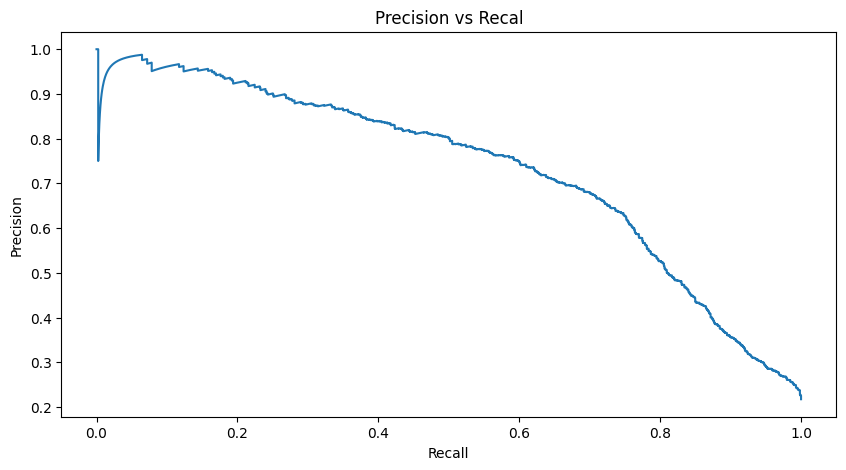

In [201]:
plt.figure(figsize=(10, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs Recal')
plt.show()

The precision-recall curve highlights the trade-off between identifying more default cases and maintaining prediction accuracy.

We can identify a negative correlation between Precision and Recall. As the Recall increases, the Precision decreases. This means that to identify a larger percentage of borrowers who will default, the model would also have a higher number of false predictions.

The area under the precision-recall curve, a PR-AUC score of 0.73, indicates that the Logistic Regression model performs reasonably well at separating default and non-default borrowers, although there is still room for significant improvement.

### Decision Tree

In [202]:
# Using GridSearch along with the DecisionTreeClassifier to test multiple max_depths and select the best performing option through cross-validation
# dealing with the best max_depth to prevent overfitting

tree_model = DecisionTreeClassifier(random_state=5)

# list of depths to test
depth_test = {'max_depth' : [2, 3, 5, 7, 9, 10, None]}

# split dataset into 5 parts to validate each depth
determined_depth = GridSearchCV(estimator=tree_model, param_grid=depth_test, cv = 5, scoring="roc_auc")

# fitting the data
determined_depth.fit(X_train, y_train)

# finding the best depth
print(f"Best Depth: {determined_depth.best_params_['max_depth']}")
print(f"Best CV AUC: {determined_depth.best_score_:.4f}")

# best fitted tree
best_tree = determined_depth.best_estimator_

# class predictions
dt_prediction = determined_depth.predict(X_test)

# probability predictions for AUC
dt_proba = best_tree.predict_proba(X_test)[:, 1]

dt_roc_auc = roc_auc_score(y_test, dt_proba)

print(f"ROC-AUC Score: {dt_roc_auc:.4f}")

Best Depth: 9
Best CV AUC: 0.9028
ROC-AUC Score: 0.9083


### Decision Tree Analysis

In [203]:
# train_acc = determined_depth.score(X_train, y_train)
# test_acc = determined_depth.score(X_test, y_test)
prediction_accuracy = accuracy_score(y_test, dt_prediction)

# print(f"Train Accuracy: {train_acc:.4f}")
# print(f"Test Accuracy: {test_acc:.4f}\n")
print(f"Prediction Accuracy: {prediction_accuracy:.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_prediction))

print("\nClassification Report:")
print(classification_report(y_test, dt_prediction))

precision, recall, threshold = precision_recall_curve(y_test, dt_proba)
dt_pr_auc = auc(recall, precision)
print(f"PR AUC Score: {dt_pr_auc:.4f}")

Prediction Accuracy: 0.9181

Confusion Matrix:
[[4359  102]
 [ 365  873]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      4461
           1       0.90      0.71      0.79      1238

    accuracy                           0.92      5699
   macro avg       0.91      0.84      0.87      5699
weighted avg       0.92      0.92      0.91      5699

PR AUC Score: 0.8522


The accuracy of the Decision Tree model is 92% which is higher than that of the Logistic Regression Model. This indicates that the Decision Tree model is  better at predicting whether a borrower will default and is less likely to just guess a non-defualt when compared to the Logistic Regression Model.

This is further backed up when observing the confusion matrix and classification report. The number of False Negatives in the confusion matrix decreased substantially, revealing a decrease in the number of non-defualts guessed which were wrong. Also, the predicting and recall score for a default significantly increased meaning it is more accurate when predicting a default on the loan.

A more in-depth analysis of the classification report reveals that the model achieves a high precision of 90% while maintaining a recall of 71%, indicating that when it predicts a default it is usually correct while still identifying a large proportion of actual default cases. The recall score for non-default borrowers increased to 98%, showcasing that the model is highly effective at identifying borrowers with the ability to repay their loans.

In summary, this model makes fewer incorret predictions and is significantly more accurate in comparison to the previous model and would be better when trying to identify eligible candidates to provide a loan given the same attributes observed in the dataset.

In [204]:
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': determined_depth.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                        Feature  Importance
5           loan_percent_income    0.308271
4                 loan_int_rate    0.201476
9    person_home_ownership_RENT    0.194404
1                 person_income    0.091134
12          loan_intent_MEDICAL    0.035009
2             person_emp_length    0.032554
16                 loan_grade_C    0.031869
17                 loan_grade_D    0.031344
14          loan_intent_VENTURE    0.019928
11  loan_intent_HOMEIMPROVEMENT    0.012053


The Decision Tree model ranks loan_percent_income as the most important feature, and loan_int_rate and if a borrower rents their home as the next most important features.

This aligns closely with what was identified and predicted from the exploratory data analysis. Borrowers whose loan was a higher percentage of their income and those with a high interest rate seemed to have an increased risk of defaulting on their loan.

Borrowers who rent their homes may have less financial stability than homeowners.

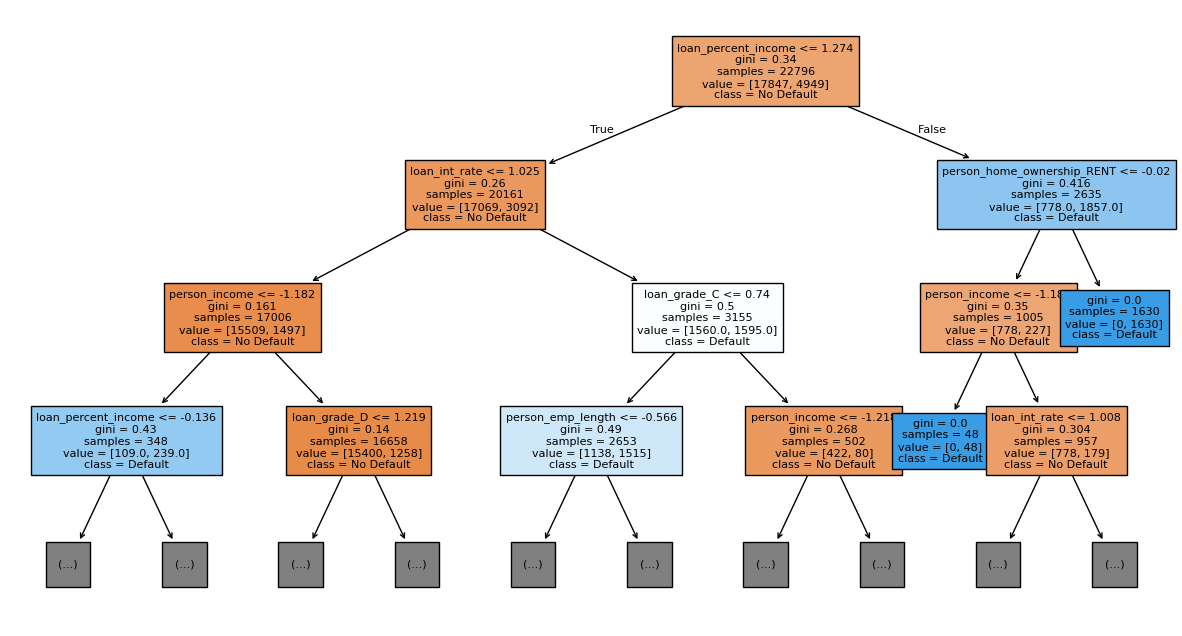

In [205]:
plt.figure(figsize=(15,8))

plot_tree(
    determined_depth.best_estimator_,
    max_depth=3,
    filled=True,
    feature_names=x_train.columns,
    class_names=["No Default", "Default"],
    fontsize=8
)

plt.show()

The Decision Tree shows that loan_percent_income is used on the first level of the tree as the variable to split the data. The second level of the tree shows that loan_int_rate and person_home_ownership are used to further split the data.

This indicates that those variables provide the most information on whether a borrower is going to default. As the tree continues on towards the lower level, more factors are included which could be used to refine and improve the prediction.

The structure of the decision tree reinforces the feature importance analysis and also supports the conclusions reached during exploratory data analysis.

### Random Forest

In [206]:
# TODO: Include a Random Forest Algorithm

rf_model = RandomForestClassifier(n_estimators=100, random_state=1)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

In [207]:
rf_acc = accuracy_score(y_test, rf_prediction) * 100
print(f"Random Forest Accuracy: {rf_acc:.2f}%")

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_prediction))

# Classification report
print("Classification Report:")
print(classification_report(y_test, rf_prediction))

# Precision-recall AUC
rf_scores = rf_model.predict_proba(X_test)[:, 1]

rf_roc_auc = roc_auc_score(y_test, rf_scores)
print(f"ROC-AUC Score: {rf_roc_auc:.4f}")


precision, recall, thresholds = precision_recall_curve(y_test, rf_scores)
rf_auc = auc(recall, precision)

print(f"Random Forest PR-AUC: {rf_auc:.4f}")

Random Forest Accuracy: 93.03%
Confusion Matrix:
[[4406   55]
 [ 342  896]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4461
           1       0.94      0.72      0.82      1238

    accuracy                           0.93      5699
   macro avg       0.94      0.86      0.89      5699
weighted avg       0.93      0.93      0.93      5699

ROC-AUC Score: 0.9287
Random Forest PR-AUC: 0.8821


The Random Forest Model performs better in almost all aspects such as accuracy, precision and recall value compared to the Decision Tree Model, although not by very much. Its AUC score is also higher, meaning it has a better understanding of the data and is able to more accurately distinguish between if a borrower would default or not.

We can see the improvements continue when comparing their confusion matrices, as its False Positive and False Negative values are also lower than that of the Decision Tree Model.

Compared to the Decision Tree Model, the Random Forest increased default recall from 71% to 72%. Meaning it was able to successfully identify a greater percentage of borrowers who would actually default. The Random Forest model also reduced false negatives from 365 to 342. This is important because false negatives represent borrowers who are incorrectly classified as safe when they are actually likely to default. For a lender, reducing false negatives lowers financial risk and improves decision making.

In [208]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))

                       Feature  Importance
5          loan_percent_income    0.210967
1                person_income    0.141285
4                loan_int_rate    0.137875
3                    loan_amnt    0.078076
9   person_home_ownership_RENT    0.077076
2            person_emp_length    0.061046
17                loan_grade_D    0.059994
0                   person_age    0.048763
6   cb_person_cred_hist_length    0.038137
8    person_home_ownership_OWN    0.018627


Importance Analysis:

During EDA, loan_percent_income and loan_int_rate showed strong relationships with default status. The Random Forest model also ranked these features among the most important predictors, thus supporting the patterns identified during exploratory analysis.

The agreement between the EDA findings and the Random Forest feature importance rankings increases confidence that these variables are genuinely influential predictors rather than random patterns in the dataset.

All models compared:



| Model | Acuracy | Precision (default)| Recall | F1 | PR-AUC | ROC-AUC|
| --- | --- | --- | --- | --- | --- | --- |
| Logistic Regression | 0.8675 | 0.77 | 0.56 | 0.65 | 0.732 | 0.8737|
| Decision Tree | 0.9181 | 0.90 | 0.71 | 0.79 | 0.8522 | 0.9083 |
| Random Forest | 0.9303 | 0.94 | 0.72 | 0.82 | 0.8821 | 0.9287 |

Although the improvements from Decision Tree to Random Forest is relatively small, even a 1% increase in recall reduces financail risk by a signicicant amount when reviewing thousands of loan applications.

The Random Forest model achieved the highest accuracy (93.03%), Precision (94%), Recall (72%), PR-AUC (0.8821), and ROC-AUC (0.9287), making it the strongest performed in every metric evaluated in this project. The Random Forest model is able to perform best because it is able to map complex, non-linear relationships. Compared to a single decision tree which easily overfits and logistic regression which is limited to linear assumptions, the random forest combines many decision trees and thereby reduces the overfitting that can be experienced in a single decision tree.

Final Recommendation :

If I was a real lender, I would choose to go with the Random Forest Model in order to determined who to lend to. This model shows to have the highest accuracy, precision, and recall values compared to the Decision Tree and Logistic Regression Models. Therefore, it would be the preferred model for identifying high-risk borrowers and reducing the likelihood of lending to individuals who may default on their loans.